In [1]:
import time

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
from flax.training.train_state import TrainState

from flightning import FLIGHTNING_PATH
from flightning.algos import ppo
from flightning.envs import rollout, HoveringStateEnv
from flightning.envs.wrappers import (
    MinMaxObservationWrapper,
    NormalizeActionWrapper,
)
from flightning.modules import ActorCriticPPO

%matplotlib inline

# Training a State-based Quadrotor Policy With PPO

## Seed it

All JAX computations are deterministic: Given the same inputs, we get the same outputs. Therefore, we need to use random keys whereever we want to sample from a distributution. Here, we need it to initialize the networks and later set the initial random key for the training.

In [2]:
seed = 0
key = jax.random.key(seed)
key_init, key_ppo = jax.random.split(key, 2)

## Setup the Training Environment

In [3]:
drone_path = FLIGHTNING_PATH + "/objects/quadrotor_files/example_quad.yaml"
dt = 0.02

env = HoveringStateEnv(
    max_steps_in_episode=3 * int(1 / dt),
    dt=dt,
    delay=0.03,
    velocity_std=0.1,
    yaw_scale=1.0,
    pitch_roll_scale=0.1,
    omega_std=0.1,
    drone_path=drone_path,
    reward_sharpness=5.0,
    action_penalty_weight=0.5,
)
env = MinMaxObservationWrapper(env)
env = NormalizeActionWrapper(env)

# get dims
action_dim = env.action_space.shape[0]
obs_dim = env.observation_space.shape[0]

## Define the Actor and Critic

In [4]:
policy_net = ActorCriticPPO(
    [obs_dim, 512, 512, action_dim], initial_log_std=jnp.log(0.5)
)

Since all objects we are working with are state-less, the parameters are handles separately from the model architecture.

In [5]:
policy_params = policy_net.initialize(key_init)

## Setup the Optimizer and Train State

The optimizer is the method that will update the network parameters. In our case, we use the Adam optimizer. The train state contains information on how to call the network, the current parameters, and the optimizer.

In [6]:
tx = optax.adam(3e-4)
train_state = TrainState.create(
    apply_fn=policy_net.apply, params=policy_params, tx=tx
)

## Initial Rollout

We define a function to do parallel rollouts, a policy function that packages the network structure and the initial parameters, and we rollout the policy.

In [7]:
# Just for sanity check

def get_rollouts(env, policy, num_rollouts, key):
    parallel_rollout = jax.vmap(rollout, in_axes=(None, 0, None))
    rollout_keys = jax.random.split(key, num_rollouts)
    transitions = parallel_rollout(env, rollout_keys, policy)
    return transitions


def policy(obs, key):
    pi = train_state.apply_fn(train_state.params, obs).pi
    return pi.sample(seed=key)


transitions = get_rollouts(env, policy, 10, jax.random.key(3))

/home/nat-nus/apg/rpg_flightning/flightning/envs/hovering_state_env.py:376: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


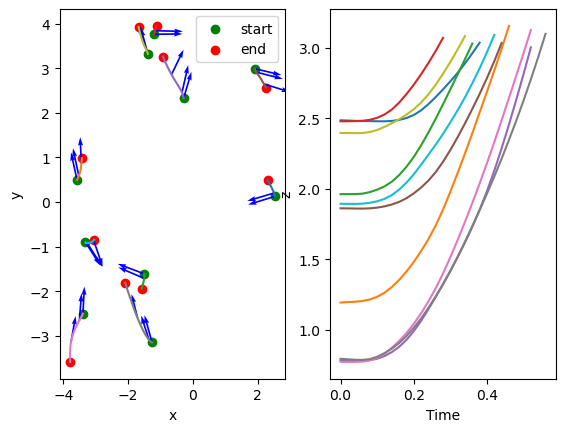

In [8]:
env.plot_trajectories(transitions)

## Train the Policy Using PPO

In [9]:
time_start = time.time()
res_dict = ppo.train(
    env,
    train_state,
    num_epochs=200,
    num_steps_per_epoch=env.max_steps_in_episode,
    num_envs=1000,
    key=key_ppo,
    config=ppo.Config(
        num_minibatches=20, ent_coef=0.01, gamma=0.99, update_epochs=4
    ),
)
time_train = time.time() - time_start
print(f"Training time: {time_train}")

Epoch: 0, Return: -30.55
Epoch: 10, Return: -22.58
Epoch: 20, Return: -21.60
Epoch: 30, Return: -16.38
Epoch: 40, Return: -14.76
Epoch: 50, Return: -12.85
Epoch: 60, Return: -11.40
Epoch: 70, Return: -10.38
Epoch: 80, Return: -9.60
Epoch: 90, Return: -8.71
Epoch: 100, Return: -7.71
Epoch: 110, Return: -6.98
Epoch: 120, Return: -6.34
Epoch: 130, Return: -6.01
Epoch: 140, Return: -5.85
Epoch: 150, Return: -5.52
Epoch: 160, Return: -5.47
Epoch: 170, Return: -5.43
Epoch: 180, Return: -5.37
Epoch: 190, Return: -5.38
Training time: 40.614283084869385


The `res_dict`contains the history of rewards and the updated training state. Let's have a look at the learning curve

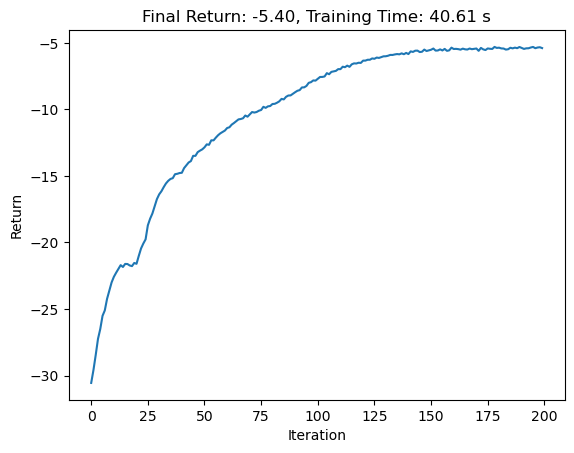

In [10]:
episode_returns = res_dict["metrics"]["returned_episode_returns"]
returned_episode = res_dict["metrics"]["returned_episode"]
returns = episode_returns * returned_episode
num_returned_episodes = returned_episode.sum(axis=(1, 2))
mean_returns = returns.sum(axis=(1, 2)) / num_returned_episodes

plt.figure()
plt.plot(jnp.array(mean_returns))
plt.title(
    f"Final Return: {mean_returns[-1]:.2f}, Training Time: {time_train:.2f} s"
)
plt.xlabel("Iteration")
plt.ylabel("Return")
plt.show()

## Evaluate the Trained Policy

Get the updated Policy Parameters and Create a new Policy function

In [11]:
new_train_state = res_dict["runner_state"].train_state

def policy_trained(obs, key):
    pi = new_train_state.apply_fn(new_train_state.params, obs).pi
    return pi.mean()  # pi.sample(seed=key)

Define the evaluation environment and collect the new rollouts.

In [12]:
env_eval = HoveringStateEnv(
    max_steps_in_episode=10 * int(1 / dt),
    dt=dt,
    delay=0.03,
    velocity_std=0.1,
    yaw_scale=1.0,
    pitch_roll_scale=0.1,
    omega_std=0.1,
    drone_path=drone_path,
)
env_eval = MinMaxObservationWrapper(env_eval)
env_eval = NormalizeActionWrapper(env_eval)

transitions_eval = get_rollouts(env_eval, policy_trained, 20, jax.random.key(3))

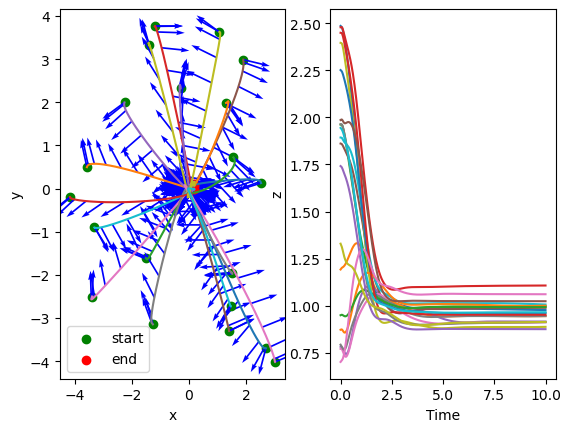

In [13]:
env_eval.plot_trajectories(transitions_eval)